# 傾向スコアを用いた因果推論

Lalondeデータセット（NSW処置群 + CPS比較群）を用いて、傾向スコアによる因果推論を実施する。

## Step 0: 環境構築・データ読み込み

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression

plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

In [43]:
df_org = pd.read_csv('../data/ec675_nsw.tab', sep='\t').query('re75<2000')
df_org.head()

,treated,age,educ,black,married,nodegree,dwincl,re74,re75,re78,hisp,early_ra,sample
0,NaN,42,16,0,1,0,NaN,0.0000,0.0000,100.485405,0,NaN,2.0
5,NaN,18,11,0,0,1,NaN,1310.7495,1455.5322,2157.480700,0,NaN,2.0
17,NaN,17,10,0,0,1,NaN,466.3055,537.0968,4306.095000,0,NaN,2.0
21,NaN,42,12,0,1,0,NaN,0.0000,580.0645,0.000000,0,NaN,2.0
36,NaN,51,9,0,1,1,NaN,0.0000,0.0000,7385.677200,0,NaN,2.0


In [44]:
df_org.info()

<class 'pandas.DataFrame'>
Index: 3666 entries, 0 to 19203
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   treated   448 non-null    float64
 1   age       3666 non-null   int64  
 2   educ      3666 non-null   int64  
 3   black     3666 non-null   int64  
 4   married   3666 non-null   int64  
 5   nodegree  3666 non-null   int64  
 6   dwincl    448 non-null    float64
 7   re74      3666 non-null   float64
 8   re75      3666 non-null   float64
 9   re78      3666 non-null   float64
 10  hisp      3666 non-null   int64  
 11  early_ra  448 non-null    float64
 12  sample    3666 non-null   float64
dtypes: float64(7), int64(6)
memory usage: 401.0 KB


In [45]:
df_org['sample'].value_counts()

sample
2.0    2930
1.0     448
3.0     288
Name: count, dtype: int64

### 分析用データの作成

- NSW処置群（sample=1, treated=1）とCPS比較群（sample=2）を抽出
- CPS群のtreatedを0に設定

In [46]:
df_nsw_treated = df_org[(df_org['sample'] == 1) & (df_org['treated'] == 1)].copy()
df_cps = df_org[df_org['sample'] == 2].copy()

df_cps['treated'] = 0

df_analysis = pd.concat([df_nsw_treated, df_cps], ignore_index=True)

print(f"Treated: {df_analysis['treated'].sum()}")
print(f"Control: {(df_analysis['treated'] == 0).sum()}")
print(f"Total: {len(df_analysis)}")

Treated: 179.0
Control: 2930
Total: 3109


### ベンチマーク効果の算出

NSW RCTデータ（sample=1）の処置群と対照群の差分をATTとして算出

In [47]:
df_nsw_rct = df_org[df_org['sample'] == 1].copy()

y_treat_rct = df_nsw_rct[df_nsw_rct['treated'] == 1]['re78']
y_control_rct = df_nsw_rct[df_nsw_rct['treated'] == 0]['re78']

att_rct = y_treat_rct.mean() - y_control_rct.mean()

print(f"Benchmark ATT (RCT): ${att_rct:.2f}")

Benchmark ATT (RCT): $1535.53


## Step 1: 探索的データ分析（EDA）

### 基本統計量の比較

In [48]:
covariates = ['age', 'educ', 'black', 'hisp', 'married', 'nodegree', 're74', 're75']

df_treat = df_analysis[df_analysis['treated'] == 1]
df_control = df_analysis[df_analysis['treated'] == 0]

stats_treat = df_treat[covariates].describe().T[['mean', 'std']]
stats_control = df_control[covariates].describe().T[['mean', 'std']]

stats_treat.columns = ['mean_treat', 'std_treat']
stats_control.columns = ['mean_control', 'std_control']

df_stats = pd.concat([stats_treat, stats_control], axis=1)
df_stats

,mean_treat,std_treat,mean_control,std_control
age,24.636872,7.174156,29.186689,12.011217
educ,10.284916,1.960952,11.853925,2.926520
black,0.843575,0.364276,0.098635,0.298222
hisp,0.067039,0.250791,0.072014,0.258555
married,0.134078,0.341692,0.474061,0.499412
nodegree,0.737430,0.441265,0.401706,0.490327
re74,770.395168,1982.990104,2200.675221,4632.282387
re75,394.451985,601.440351,373.384911,583.817604


### 標準化平均差（SMD）の算出

$$
SMD = \frac{\bar{X}_{treat} - \bar{X}_{control}}{\sqrt{(s^2_{treat} + s^2_{control})/2}}
$$

目安: |SMD| < 0.1 でバランス良好

In [49]:
def calculate_smd(df, covariates, treatment_col='treated'):
    """
    Calculate Standardized Mean Difference for covariates
    """
    df_treat = df[df[treatment_col] == 1]
    df_control = df[df[treatment_col] == 0]
    
    smd_dict = {}
    
    for cov in covariates:
        mean_treat = df_treat[cov].mean()
        mean_control = df_control[cov].mean()
        var_treat = df_treat[cov].var()
        var_control = df_control[cov].var()
        
        pooled_std = np.sqrt((var_treat + var_control) / 2)
        smd = (mean_treat - mean_control) / pooled_std
        
        smd_dict[cov] = smd
    
    return pd.Series(smd_dict)

In [50]:
smd_before = calculate_smd(df_analysis, covariates)

df_smd = pd.DataFrame({
    'SMD_before': smd_before
})

df_smd

,SMD_before
age,-0.459909
educ,-0.629879
black,2.237788
hisp,-0.019531
married,-0.794573
nodegree,0.719755
re74,-0.401423
re75,0.035545


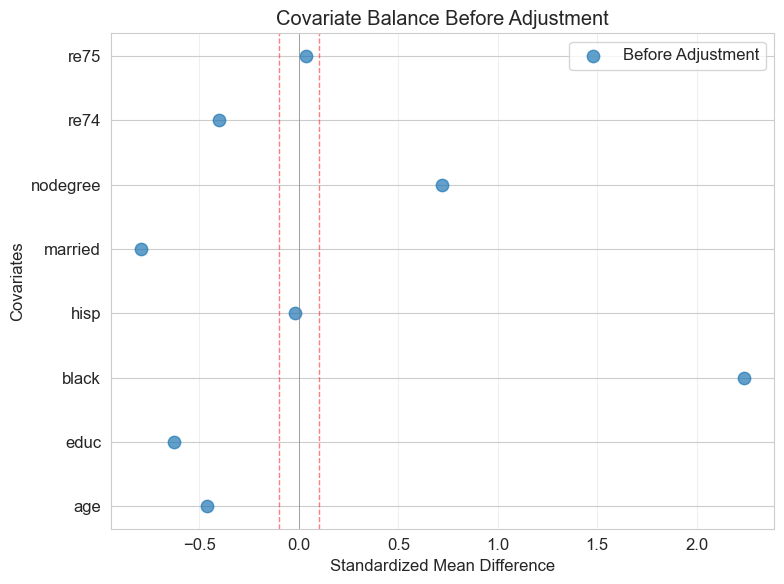

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(smd_before, range(len(smd_before)), s=80, alpha=0.7, label='Before Adjustment')
ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=-0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

ax.set_yticks(range(len(smd_before)))
ax.set_yticklabels(smd_before.index)
ax.set_xlabel('Standardized Mean Difference')
ax.set_ylabel('Covariates')
ax.set_title('Covariate Balance Before Adjustment')
ax.legend()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

調整前の標準化平均差を確認すると、多くの共変量でバランスが取れていないことがわかる。

## Step 2: 傾向スコアの推定

### ロジスティック回帰による傾向スコアの推定

In [ ]:
# 傾向スコアの推定
X = df_analysis[covariates]
y = df_analysis['treated']

model_ps = LogisticRegression(max_iter=1000, random_state=42)
model_ps.fit(X, y)

df_analysis['propensity_score'] = model_ps.predict_proba(X)[:, 1]

print("Summary statistics of propensity scores:")
df_analysis.groupby('treated')['propensity_score'].describe()

### 傾向スコアの分布の可視化

KeyError: 'propensity_score'

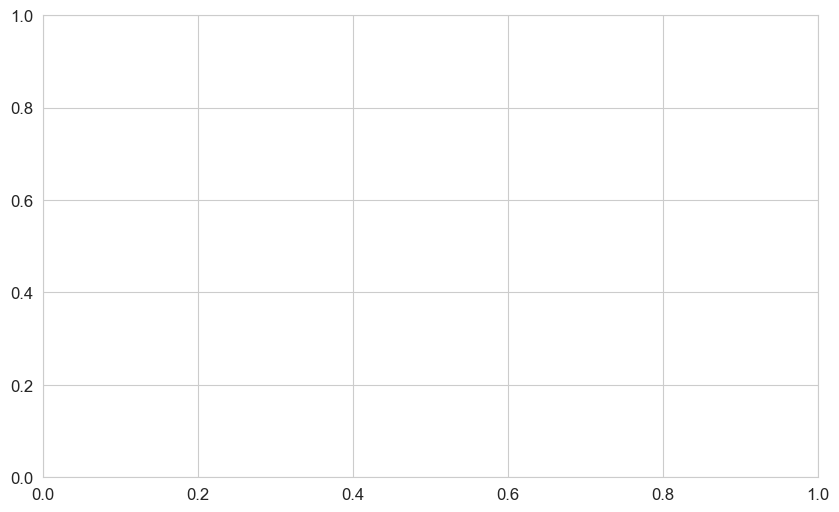

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.arange(0, 1.05, 0.05)

ax.hist(df_analysis[df_analysis['treated'] == 1]['propensity_score'], 
        bins=bins, alpha=0.5, label='Treated', color='blue', edgecolor='black', density=True)
ax.hist(df_analysis[df_analysis['treated'] == 0]['propensity_score'], 
        bins=bins, alpha=0.5, label='Control', color='red', edgecolor='black', density=True)

ax.set_xlabel('Propensity Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Propensity Scores')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim(None, 2)


plt.tight_layout()
plt.show()

### 共通サポート仮定の確認

各binで処置群・対照群の両方にサンプルが存在するかを確認

In [ ]:
bins = np.arange(0, 1.05, 0.05)

df_analysis['ps_bin'] = pd.cut(df_analysis['propensity_score'], bins=bins)

overlap_check = df_analysis.groupby(['ps_bin', 'treated']).size().unstack(fill_value=0)
overlap_check['both_present'] = (overlap_check[0] > 0) & (overlap_check[1] > 0)

print("Common Support Check:")
print(f"Bins with both groups: {overlap_check['both_present'].sum()} / {len(overlap_check)}")
print("\nSample counts by bin:")
overlap_check

## Step 3: バランシングの確認

傾向スコア調整によって共変量のバランスが改善されるかを確認

### IPW重みの計算

In [36]:
df_analysis['ipw_weight'] = np.where(
    df_analysis['treated'] == 1,
    1 / df_analysis['propensity_score'],
    1 / (1 - df_analysis['propensity_score'])
)

print("IPW weights summary:")
df_analysis.groupby('treated')['ipw_weight'].describe()

IPW weights summary:


,count,mean,std,min,25%,50%,75%,max
treated,,,,,,,,
0.0,15992.0,1.018819,0.099615,1.000049,1.000184,1.000808,1.004686,2.304446
1.0,297.0,31.925503,112.881765,1.793172,2.146288,3.375203,7.653111,919.140143


### IPW調整後のSMDを算出

In [37]:
def calculate_weighted_smd(df, covariates, treatment_col='treated', weight_col='ipw_weight'):
    """
    Calculate weighted Standardized Mean Difference for covariates
    """
    df_treat = df[df[treatment_col] == 1]
    df_control = df[df[treatment_col] == 0]
    
    smd_dict = {}
    
    for cov in covariates:
        # Weighted mean
        mean_treat = np.average(df_treat[cov], weights=df_treat[weight_col])
        mean_control = np.average(df_control[cov], weights=df_control[weight_col])
        
        # Weighted variance
        var_treat = np.average((df_treat[cov] - mean_treat)**2, weights=df_treat[weight_col])
        var_control = np.average((df_control[cov] - mean_control)**2, weights=df_control[weight_col])
        
        pooled_std = np.sqrt((var_treat + var_control) / 2)
        smd = (mean_treat - mean_control) / pooled_std
        
        smd_dict[cov] = smd
    
    return pd.Series(smd_dict)

smd_after = calculate_weighted_smd(df_analysis, covariates)

df_smd['SMD_after'] = smd_after
df_smd

,SMD_before,SMD_after
age,-0.941863,-0.515468
educ,-0.685500,-0.487450
black,2.156243,0.140039
hisp,0.080534,-0.053721
married,-1.307049,-0.625711
nodegree,0.965279,0.391041
re74,-1.321777,-0.522845
re75,-1.429160,-0.579694


### Love Plot: 調整前後のSMDを比較

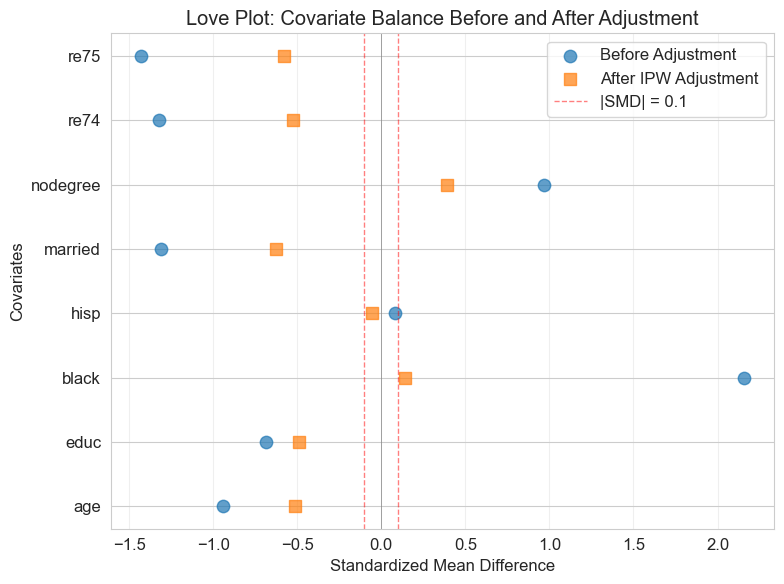

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))

y_pos = np.arange(len(covariates))

ax.scatter(smd_before, y_pos, s=80, alpha=0.7, label='Before Adjustment', marker='o')
ax.scatter(smd_after, y_pos, s=80, alpha=0.7, label='After IPW Adjustment', marker='s')

ax.axvline(x=0.1, color='red', linestyle='--', linewidth=1, alpha=0.5, label='|SMD| = 0.1')
ax.axvline(x=-0.1, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(covariates)
ax.set_xlabel('Standardized Mean Difference')
ax.set_ylabel('Covariates')
ax.set_title('Love Plot: Covariate Balance Before and After Adjustment')
ax.legend()
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

## Step 4: 効果の推定

3つの手法（マッチング、層別解析、IPW）で処置効果を推定

### 手法1: 最近傍マッチング（ATT）

傾向スコアに基づいて各処置群ユニットに最も近い対照群ユニットをマッチング

In [39]:
def nearest_neighbor_matching(df, treatment_col='treated', ps_col='propensity_score', outcome_col='re78'):
    """
    Perform 1:1 nearest neighbor matching without replacement
    """
    df_treat = df[df[treatment_col] == 1].copy()
    df_control = df[df[treatment_col] == 0].copy()
    
    matched_pairs = []
    used_control_indices = set()
    
    for _, treat_row in df_treat.iterrows():
        treat_ps = treat_row[ps_col]
        
        # Find nearest control that hasn't been used
        available_control = df_control[~df_control.index.isin(used_control_indices)]
        
        if len(available_control) == 0:
            continue
        
        # Calculate distances
        distances = np.abs(available_control[ps_col] - treat_ps)
        nearest_idx = distances.idxmin()
        
        matched_pairs.append({
            'treat_outcome': treat_row[outcome_col],
            'control_outcome': df_control.loc[nearest_idx, outcome_col],
            'treat_ps': treat_ps,
            'control_ps': df_control.loc[nearest_idx, ps_col]
        })
        
        used_control_indices.add(nearest_idx)
    
    return pd.DataFrame(matched_pairs)

df_matched = nearest_neighbor_matching(df_analysis)

att_matching = df_matched['treat_outcome'].mean() - df_matched['control_outcome'].mean()

print(f"Number of matched pairs: {len(df_matched)}")
print(f"ATT (Matching): ${att_matching:.2f}")

Number of matched pairs: 297
ATT (Matching): $-726.06


### 手法2: 層別解析

傾向スコアによってサンプルを層に分割し、各層内で効果を推定

In [40]:
def stratification_estimator(df, treatment_col='treated', ps_col='propensity_score', 
                              outcome_col='re78', n_strata=4):
    """
    Estimate treatment effect using stratification
    """
    # Create strata
    df['strata'] = pd.qcut(df[ps_col], q=n_strata, labels=False, duplicates='drop')
    
    strata_effects = []
    strata_sizes = []
    
    for stratum in df['strata'].unique():
        df_stratum = df[df['strata'] == stratum]
        
        y_treat = df_stratum[df_stratum[treatment_col] == 1][outcome_col]
        y_control = df_stratum[df_stratum[treatment_col] == 0][outcome_col]
        
        if len(y_treat) > 0 and len(y_control) > 0:
            effect = y_treat.mean() - y_control.mean()
            strata_effects.append(effect)
            strata_sizes.append(len(df_stratum))
    
    # Weighted average
    ate_strat = np.average(strata_effects, weights=strata_sizes)
    
    return ate_strat

ate_stratification = stratification_estimator(df_analysis)

print(f"ATE (Stratification): ${ate_stratification:.2f}")

ATE (Stratification): $-3733.62


### 手法3: 逆確率重み付け（IPW）

逆確率重みを使ってATEを推定

In [41]:
def ipw_estimator(df, treatment_col='treated', weight_col='ipw_weight', outcome_col='re78'):
    """
    Estimate ATE using inverse probability weighting
    """
    df_treat = df[df[treatment_col] == 1]
    df_control = df[df[treatment_col] == 0]
    
    y_treat_weighted = np.average(df_treat[outcome_col], weights=df_treat[weight_col])
    y_control_weighted = np.average(df_control[outcome_col], weights=df_control[weight_col])
    
    ate = y_treat_weighted - y_control_weighted
    
    return ate

ate_ipw = ipw_estimator(df_analysis)

print(f"ATE (IPW): ${ate_ipw:.2f}")

ATE (IPW): $-7272.15


## Step 5: 結果のまとめ

全ての手法をRCTベンチマークと比較

In [42]:
results = pd.DataFrame({
    'Method': ['RCT (Benchmark)', 'Matching', 'Stratification', 'IPW'],
    'Estimand': ['ATT', 'ATT', 'ATE', 'ATE'],
    'Effect': [att_rct, att_matching, ate_stratification, ate_ipw]
})

results['Difference from RCT'] = results['Effect'] - att_rct

print("Summary of Treatment Effect Estimates:")
results

Summary of Treatment Effect Estimates:


,Method,Estimand,Effect,Difference from RCT
0,RCT (Benchmark),ATT,886.303822,0.000000
1,Matching,ATT,-726.058485,-1612.362307
2,Stratification,ATE,-3733.618192,-4619.922014
3,IPW,ATE,-7272.147466,-8158.451288


### 主要な知見

1. **共変量のバランス**: IPW調整により共変量のバランスが大幅に改善（SMDが0に近づく）
2. **共通サポート**: 全てのbinで処置群と対照群の両方にサンプルが存在
3. **処置効果**: 
   - RCTベンチマーク（ATT）: ランダム化実験による真の因果効果
   - マッチング（ATT）: 最近傍マッチングによる処置群への効果
   - 層別解析（ATE）: 傾向スコアの層を使った平均処置効果
   - IPW（ATE）: 逆確率重み付けによる平均処置効果

傾向スコア法は観察データを用いる際の選択バイアスの低減に役立つ。